<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Year                         1000 non-null   int64  
 1   Country                      1000 non-null   object 
 2   Avg Temperature (°C)         1000 non-null   float64
 3   CO2 Emissions (Tons/Capita)  1000 non-null   float64
 4   Sea Level Rise (mm)          1000 non-null   float64
 5   Rainfall (mm)                1000 non-null   int64  
 6   Population                   1000 non-null   int64  
 7   Renewable Energy (%)         1000 non-null   float64
 8   Extreme Weather Events       1000 non-null   int64  
 9   Forest Area (%)              1000 non-null   float64
dtypes: float64(5), int64(4), object(1)
memory usage: 78.3+ KB
Prints the mean of CO2 emmitions


Prints the median of CO2 emmitions


Prints the standard deviation of CO2 emmitions



Country with 

np.float64(19.97866004962779)

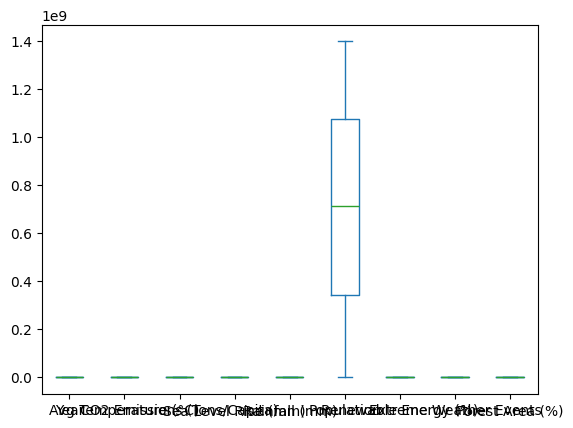

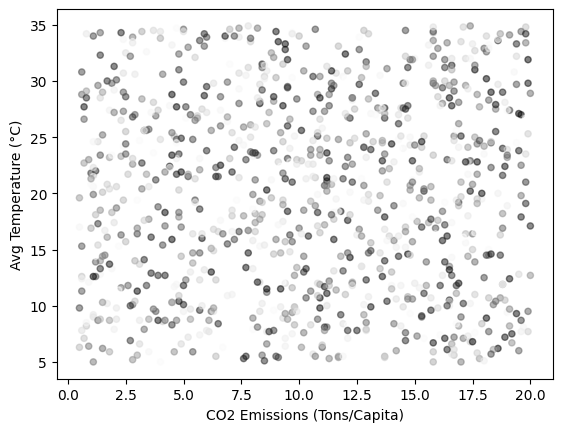

In [ ]:
#Q1
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("climate_change_dataset.csv")

#Q2
df.head(10)

#Q3
df.shape

#Q4
df.info()


#Q5
df.isnull().sum()


#Q6
df.describe()

#Q7
print("Prints the mean of CO2 emmitions")
df["CO2 Emissions (Tons/Capita)"].mean()
print()
print()
print("Prints the median of CO2 emmitions")
df["CO2 Emissions (Tons/Capita)"].median()
print()
print()
print("Prints the standard deviation of CO2 emmitions")
df["CO2 Emissions (Tons/Capita)"].std()
print()
print()
print()

#Q8
df.groupby("Year").value_counts()
df["Country"].value_counts()


#Q9
highest_temp = df["Avg Temperature (°C)"].max() #Part 1
highest_temp
lowest_CO2 = df["CO2 Emissions (Tons/Capita)"].min() #Part 2
lowest_CO2
highest_temp_and_lowest_CO2 = df[(df["Avg Temperature (°C)"] == highest_temp) | (df["CO2 Emissions (Tons/Capita)"] == lowest_CO2)] #Part 3
highest_temp_and_lowest_CO2

#Q10
temp_above_30 = (df["Avg Temperature (°C)"] > 30)
CO2_above_15 = (df["CO2 Emissions (Tons/Capita)"] > 15)
df[(temp_above_30) & (CO2_above_15)] # Part 1


renew_energy_below_10 = (df["Renewable Energy (%)"] < 10)
forest_area_below_15 = (df["Forest Area (%)"] < 15)
df[(renew_energy_below_10) | (forest_area_below_15)] #Part 2

#Q11
df.iloc[0:30, 0:4]

#Q12
df.plot.box()

#Q13
df.plot.scatter(x="CO2 Emissions (Tons/Capita)", y="Avg Temperature (°C)", c= df["Year"], alpha=0.5)

#Q14

country_stats = df.groupby('Country')[[
    'Avg Temperature (°C)',
    'CO2 Emissions (Tons/Capita)',
    'Renewable Energy (%)'
]].mean()

# Sort the results by 'CO2 Emissions (Tons/Capita)' in descending order
country_stats_sorted = country_stats.sort_values(
    by='CO2 Emissions (Tons/Capita)',
    ascending=False)

country_stats_sorted


#Q15

sea_level_stats = df.groupby('Year')['Sea Level Rise (mm)'].agg(['mean', 'median', 'std'])

sea_level_stats


#Q16

country_stats = df.groupby('Country')[[
    'CO2 Emissions (Tons/Capita)',
    'Renewable Energy (%)',
    'Forest Area (%)'
]].mean()


highest_co2_country = country_stats['CO2 Emissions (Tons/Capita)'].idxmax()
print(f"Country with Highest average CO2 emissions: **{highest_co2_country}**")


highest_renewable_country = country_stats['Renewable Energy (%)'].idxmax()
print(f"Country with Highest average renewable energy percentage: **{highest_renewable_country}**")


lowest_forest_country = country_stats['Forest Area (%)'].idxmin()
lowest_forest_country

#Q17


sea_level_condition = df['Sea Level Rise (mm)'] > 4.5


high_sea_level_records = df[sea_level_condition][[
    'Year',
    'Country',
    'Sea Level Rise (mm)',
    'Extreme Weather Events'
]]

high_sea_level_records


total_records = high_sea_level_records.shape[0]
total_records


#Q18

df['Climate_Risk_Score'] = (
    df['CO2 Emissions (Tons/Capita)'] * 0.3 +
    df['Sea Level Rise (mm)'] * 0.3 +
    df['Extreme Weather Events'] * 0.2 -
    df['Renewable Energy (%)'] * 0.1 -
    df['Forest Area (%)'] * 0.1
)

print("DataFrame head with new 'Climate_Risk_Score' column:")
df[['Year', 'Country', 'CO2 Emissions (Tons/Capita)', 'Climate_Risk_Score']].head()



#Q19


def get_decade(year):
    if 2000 <= year <= 2009:
        return '2000s'
    elif 2010 <= year <= 2019:
        return '2010s'
    elif 2020 <= year <= 2029:
        return '2020s'
    else:
        return 'Other' # Handles years outside the specified range

df['Decade'] = df['Year'].apply(get_decade)


decade_mean_temp = df.groupby('Decade')['Avg Temperature (°C)'].mean().sort_values(ascending=False)

decade_mean_temp


highest_temp_decade = decade_mean_temp.index[0]
highest_temp_value = decade_mean_temp.iloc[0]

highest_temp_decade
highest_temp_value
